In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.parser import ParserError
import cycler
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

### Inputs

In [2]:
# Results directory
results_directory = './renamed_results/'

subbasin_id= '58308'

gauge_name= 'MREIB'

# scenario= 'ssp370' # select ssp245, ssp370 or ssp585

# start and end dates for the calculation of average annual flow
start_date= 2015

end_date= 2100

# variable
variable= 'cout' 

historical_path= '../../hds_model_v8_1/results/0058308.txt'

# Output dir

output_directory= '../outputs/'


### Analysis

Future Climate

In [3]:
def process_ensemble(results_directory: str, 
                 subbasin_id: str, 
                 scenario: str, 
                 start_date: str, 
                 end_date: str, 
                 variable: str) -> xr.DataArray:

    # List of member names to exclude
    exclude_members = [
        "CanESM5", "CNRM-CM6-1", "EC-Earth3", "IPSL-CM6A-LR", "UKESM1-0-LL",
        "NorESM2-MM", "EC-Earth3-CC", "NESM3", "EC-Earth3-Veg", "INM-CM4-8", "TaiESM1"
    ]
    
    # Check for files of required subbasin and scenario
    file_list = [os.path.join(results_directory, filename) 
                 for filename in os.listdir(results_directory) 
                 if (subbasin_id in filename) and (scenario in filename)]
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []

    # Loop through each file
    for file_path in file_list:
        # Skip files with excluded member names
        if any(member in file_path for member in exclude_members):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Drop the first row
        df = df.iloc[1:]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'), coords={'DATE': df.index, 'variable': df.columns})

        # Append the DataArray to the list
        data_arrays.append(data_array)

    # Concatenate the list of DataArrays along a new dimension 'member'
    ds = xr.concat(data_arrays, dim='member')

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Convert 'member' coordinate to float
    ds = ds.astype(float)

    # Select the specified variable from the dataset
    var_data = ds.sel(variable=variable)

    # Sort the dataset along the 'DATE' coordinate
    var_data = var_data.sortby('DATE')

    # Filter the sorted dataset to include only data between the specified dates
    var_data = var_data.sel(DATE=slice(start_date, end_date))

    # Calculate the mean of these daily means for each member to get the average annual runoff
    average_annual_runoff = var_data.groupby('DATE.dayofyear').mean(dim='DATE')

    # Drop leap day (dayofyear = 366)
    average_annual_runoff = average_annual_runoff.sel(dayofyear=~(average_annual_runoff['dayofyear'] == 366))
    
    # Shift data to start on November 1st
    dayofyear_shifted = ((average_annual_runoff['dayofyear'] - 274) % 365) + 1

    # Update the 'dayofyear' coordinate with the shifted values
    average_annual_runoff['dayofyear'] = dayofyear_shifted

    # Sort the data_array along the 'dayofyear' coordinate
    average_annual_runoff_shifted = average_annual_runoff.sortby('dayofyear')
    
    return average_annual_runoff_shifted

In [4]:
def process_historical(filepath: str, variable: str, start_date: str = '1981-01-01', end_date: str = '2015-12-31') -> pd.Series:
    # Read the tab-separated text file into a DataFrame
    sim: pd.DataFrame = pd.read_csv(filepath, delimiter='\t', index_col=0)
    
    # Drop the first row
    sim = sim.iloc[1:]
    
    # Drop all columns except for 'variable'
    sim = sim[[variable]]
    
    # Convert index to datetime
    sim.index = pd.to_datetime(sim.index)
    
    # Trim the DataFrame between dates
    sim = sim.loc[start_date:end_date]
    
    # Get the length of the DataFrame before dropping NaN values
    original_length: int = len(sim)
    
    # Convert the 'variable' column to numeric
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')
    
    # Drop NaN values if any
    sim = sim.dropna()
    
    # Get the length of the DataFrame after dropping NaN values
    new_length: int = len(sim)
    
    # Check if any NaN values were replaced
    if new_length < original_length:
        print("NaN values were replaced during conversion.")
    else:
        print("No NaN values were replaced during conversion.")

    # Filter for February 29th
#    feb_29_values = sim[(sim.index.month == 2) & (sim.index.day == 29)]
    
    # Print the values of February 29
  #  print("February 29 values:")
  #  print(feb_29_values)

   # print(f'Mean of Feb 29 Values: {feb_29_values.mean()}')
    
    # Resample the data to calculate the mean for each day of the year across all years
    sim_resampled: pd.Series = sim.groupby(sim.index.dayofyear)[variable].mean()

    # Drop leap day (dayofyear = 366) if it exists
    sim_resampled = sim_resampled[sim_resampled.index != 366]

    # Shift dayofyear to start at 306 (November 1st) and wrap around
    dayofyear_shifted = ((sim_resampled.index - 274) % 365) + 1

    # Update the index of the Series with the shifted dayofyear values
    sim_resampled.index = dayofyear_shifted

    # Sort the Series by index to ensure the correct order
    sim_shifted = sim_resampled.sort_index()
    
    return sim_shifted

In [5]:
def extract_ensemble(results_directory, subbasin_id, exclude_members=True):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes specific members.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude members if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0)

        # Drop the first row
        df = df.iloc[1:]

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along a new dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Select the specified variable from the dataset
    var_data = ds.sel(variable='cout')
    
    return var_data

In [6]:
def plot_annual_streamflow_volume(full_ensemble, start_date, end_date, gauge_name, output_directory, ensemble):
    """
    Plots annual streamflow volumes between a specified date range, including percentiles,
    min-max range, and the member with the smallest sum.
    
    Parameters:
        full_ensemble (xarray.DataArray): Data containing streamflow values across members.
        start_date (int): Start year for filtering data (e.g., 2060).
        end_date (int): End year for filtering data (e.g., 2090).
        gauge_name (str): Name of the stream gauge for the plot title.
        output_directory (str): Directory to save the plot.
    """
    # Create an empty dictionary to store annual sums for each member
    annual_sums = {}

    # Seconds in a day for conversion
    seconds_per_day = 24 * 60 * 60  # 86,400 seconds in a day

    # Loop through each member in the dataset
    for member_name in full_ensemble.member.values:
        # Select the member data
        member_data = full_ensemble.sel(member=member_name)
        
        # Ensure numeric conversion if data is stored as strings
        if member_data.dtype == object:
            member_data = member_data.astype(float)
        
        # Convert the DataArray to a DataFrame with DATE as the index
        member_df = member_data.to_dataframe(name='cout').reset_index()
        
        # Extract the year and month from the DATE column
        member_df['Year'] = member_df['DATE'].dt.year
        member_df['Month'] = member_df['DATE'].dt.month
        
        # Filter the DataFrame to include only rows between April 1st and September 30th
        filtered_df = member_df[
            (member_df['DATE'].dt.month >= 4) & (member_df['DATE'].dt.month <= 10)
        ].copy()
        
        # Convert daily flow rate (m³/s) to total daily volume (m³) by multiplying by the number of seconds in a day
        filtered_df['Daily_Volume_m3'] = filtered_df['cout'] * seconds_per_day
        
        # Group by year and calculate the annual sum of daily volumes
        annual_sum = filtered_df.groupby('Year')['Daily_Volume_m3'].sum()
        
        # Add the annual sum to the dictionary
        annual_sums[member_name] = annual_sum

    # Combine all annual sums into a single DataFrame
    annual_sums_df = pd.DataFrame(annual_sums)

    # Filter the DataFrame to include only rows where Year is between start_date and end_date
    filtered_annual_sums_df = annual_sums_df[(annual_sums_df.index >= start_date) & (annual_sums_df.index <= end_date)]

    # Sort DataFrame columns by member for consistency
    filtered_annual_sums_df = filtered_annual_sums_df.sort_index(axis=1)

    # Calculate min, max, and quartiles across columns
    min_values = filtered_annual_sums_df.min(axis=1)
    max_values = filtered_annual_sums_df.max(axis=1)
    q1_values = filtered_annual_sums_df.quantile(0.25, axis=1)  # 25th percentile
    median_values = filtered_annual_sums_df.median(axis=1)      # 50th percentile (median)
    q3_values = filtered_annual_sums_df.quantile(0.75, axis=1)  # 75th percentile
    q5_values = filtered_annual_sums_df.quantile(0.05, axis=1)  # 5th percentile
    q95_values = filtered_annual_sums_df.quantile(0.95, axis=1) # 95th percentile

    # Identify the column with the smallest sum across all years
    smallest_sum_column = filtered_annual_sums_df.sum().idxmin()
    smallest_sum_values = filtered_annual_sums_df[smallest_sum_column]

    # Specify the figure size (width, height)
    plt.figure(figsize=(14, 6))  # Width of 14 and height of 6 inches

    # Plot the shaded region (min to max)
    plt.fill_between(filtered_annual_sums_df.index, min_values, max_values, color='lightblue', alpha=0.4, label='Range (Min to Max)')

    # Plot the quartile lines
    plt.plot(filtered_annual_sums_df.index, q5_values, color='green', linestyle='-.', label='5th Percentile')
    plt.plot(filtered_annual_sums_df.index, q1_values, color='blue', linestyle='--', label='25th Percentile (Q1)')
    plt.plot(filtered_annual_sums_df.index, median_values, color='navy', linestyle='-', label='Median (Q2)')
    plt.plot(filtered_annual_sums_df.index, q3_values, color='blue', linestyle='--', label='75th Percentile (Q3)')
    plt.plot(filtered_annual_sums_df.index, q95_values, color='green', linestyle='-.', label='95th Percentile')

    # Plot the column with the smallest sum
    plt.plot(filtered_annual_sums_df.index, smallest_sum_values, color='red', linestyle='-', label=f'Member with Smallest Sum: \n'
             f'{smallest_sum_column}')

    # Add labels and title
    plt.xlabel('Year')
    plt.ylabel('Irrigation Season Streamflow Volume (m³)')
    plt.title(f'Annual Irrigation Season Streamflow Volume at {gauge_name} Between {start_date} and {end_date} for the {ensemble}')

    # Move the legend to the right
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

    # Add grid for better readability
    plt.grid(True)

    # Adjust plot to make room for the legend
    plt.tight_layout()

    # Save the plot to the output directory
    file_path_volume = os.path.join(output_directory, f'{gauge_name}_{start_date}_{ensemble}volume.png')
    plt.savefig(file_path_volume)

    # Show the plot
    plt.show()

    print(f"Plot saved at: {file_path_volume}")

    return filtered_annual_sums_df

### Analyze Ensemble

In [7]:
official_ensemble= extract_ensemble(results_directory, subbasin_id, True)
full_ensemble= extract_ensemble(results_directory, subbasin_id, False)

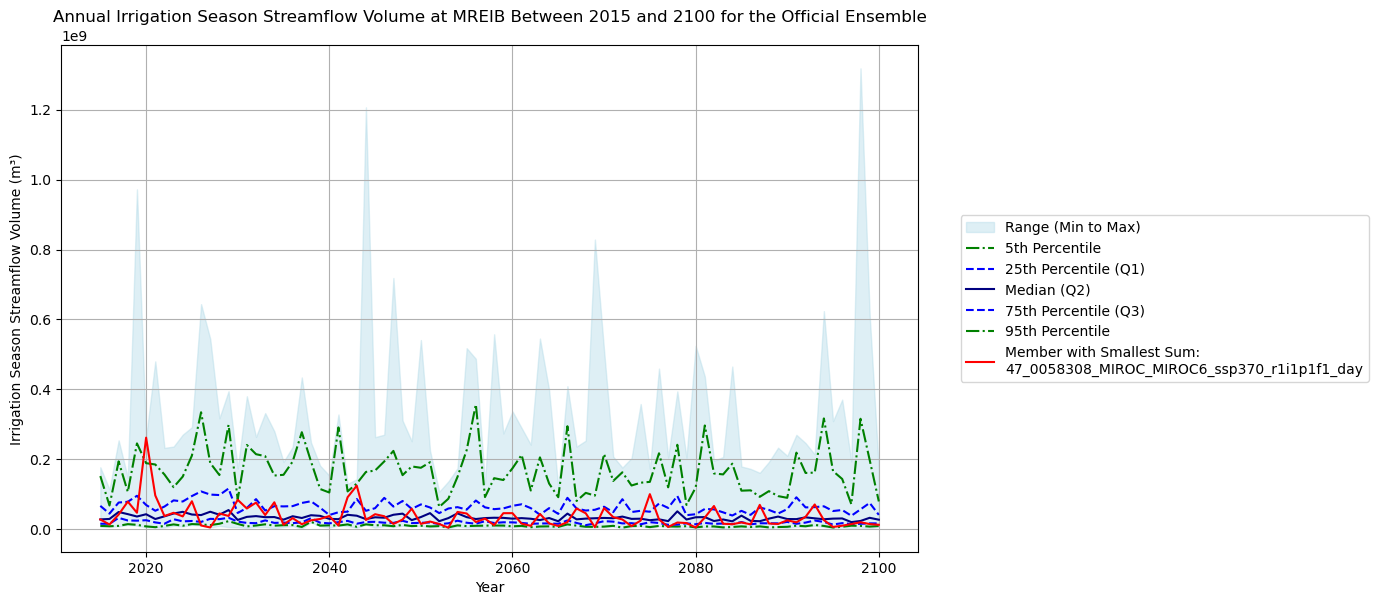

Plot saved at: ../outputs/MREIB_2015_Official Ensemblevolume.png


In [8]:
# Call the function
official_ensemble_summed= plot_annual_streamflow_volume(official_ensemble, start_date, end_date, gauge_name, output_directory, 'Official Ensemble')

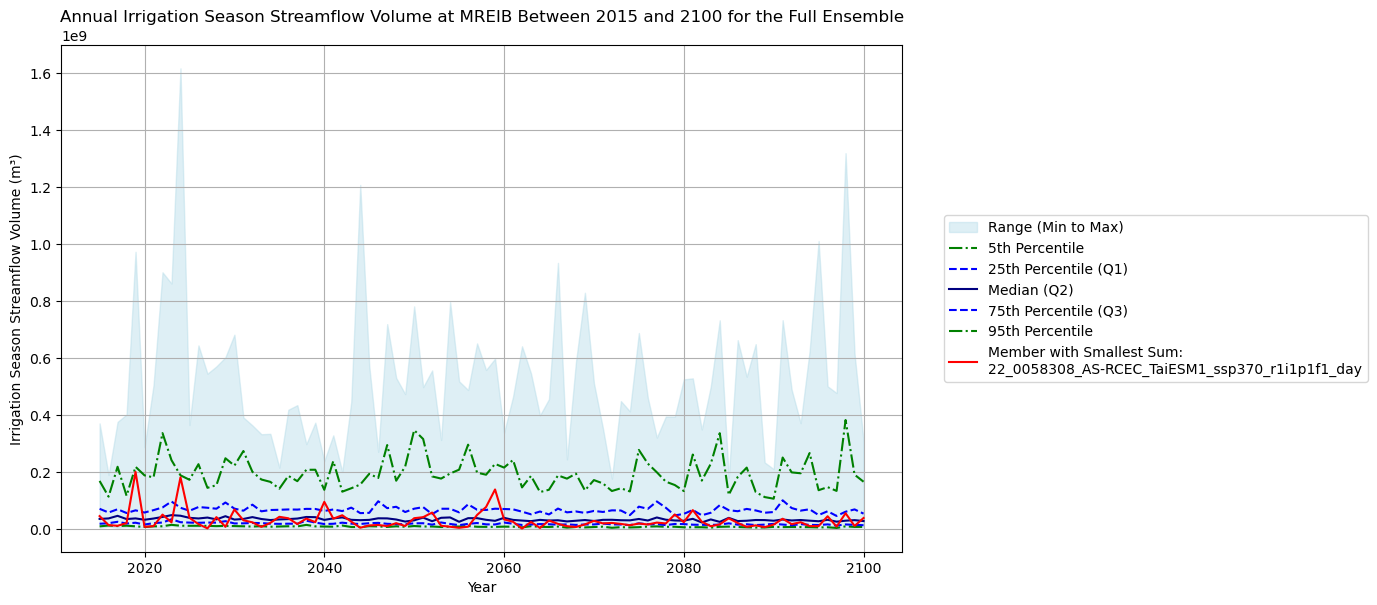

Plot saved at: ../outputs/MREIB_2015_Full Ensemblevolume.png


In [9]:
full_ensemble_summed= plot_annual_streamflow_volume(full_ensemble, start_date, end_date, gauge_name, output_directory, 'Full Ensemble')

In [12]:
official_sorted_sums_df

,Sum
Member,
47_0058308_MIROC_MIROC6_ssp370_r1i1p1f1_day,3.168110e+09
48_0058308_MIROC_MIROC6_ssp245_r1i1p1f1_day,3.242725e+09
44_0058308_MPI-M_MPI-ESM1-2-LR_ssp370_r1i1p1f1_day,3.692455e+09
40_0058308_CNRM-CERFACS_CNRM-ESM2-1_ssp370_r1i1p1f2_day,3.704500e+09
46_0058308_MPI-M_MPI-ESM1-2-LR_ssp245_r1i1p1f1_day,3.803735e+09
51_0058308_MIROC_MIROC-ES2L_ssp245_r1i1p1f2_day,3.945987e+09
27_0058308_CSIRO_ACCESS-ESM1-5_ssp370_r1i1p1f1_day,3.984887e+09
50_0058308_MIROC_MIROC-ES2L_ssp370_r1i1p1f2_day,4.035904e+09
15_0058308_NOAA-GFDL_GFDL-ESM4_ssp245_r1i1p1f1_day,4.176657e+09


In [11]:
# Sum the columns
official_column_sums = official_ensemble_summed.sum()

# Convert column sums to a DataFrame, sort, and set index to column names
official_sorted_sums_df = official_column_sums.sort_values().to_frame(name='Sum')
official_sorted_sums_df.index.name = 'Member'

# Sum the columns
full_column_sums = full_ensemble_summed.sum()

# Convert column sums to a DataFrame, sort, and set index to column names
full_sorted_sums_df = full_column_sums.sort_values().to_frame(name='Sum')
full_sorted_sums_df.index.name = 'Member'

# Merge the two DataFrames based on the index, keeping all rows from 'full_sorted_sums_df' and inserting NaN for missing values from 'official_sorted_sums_df'
merged_sums_df = full_sorted_sums_df.merge(official_sorted_sums_df, left_index=True, right_index=True, how='left', suffixes=('_full', '_official'))

In [ ]:
# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_sums_df[['Sum_full', 'Sum_official']])

# Set labels and title
plt.title(f'Total Irrigation Season Streamflow from {start_date} to {end_date} for {gauge_name}')
plt.xlabel('Ensemble')
plt.ylabel('Irrigation Season Streamflow Volume (m³) ')

# Save the plot to the output directory
file_path_comparison = os.path.join(output_directory, f'{gauge_name}_full_official_vol_comparison.png')
plt.savefig(file_path_comparison)

# Show the plot
plt.show()

### Create Plot

In [ ]:
ssp245_2030= process_ensemble(results_directory, subbasin_id, 'ssp245', '2015-01-01', '2100-01-01', variable)

In [ ]:
ssp370_2030 = process_ensemble(results_directory, subbasin_id, 'ssp370', '2015-01-01', '2100-01-01', variable)

In [ ]:
ssp585_2030= process_ensemble(results_directory, subbasin_id, 'ssp585', '2015-01-01', '2100-01-01', variable)

In [ ]:
ssp245_2060= process_ensemble(results_directory, subbasin_id, 'ssp245', '2060-01-01', '2090-12-31', variable)

In [ ]:
ssp370_2060 = process_ensemble(results_directory, subbasin_id, 'ssp370', '2060-01-01', '2090-12-31', variable)

In [ ]:
ssp585_2060= process_ensemble(results_directory, subbasin_id, 'ssp585', '2060-01-01', '2090-12-31', variable)

In [ ]:
ssp245_historical= process_ensemble(results_directory, subbasin_id, 'ssp245', '1981-01-01','2015-12-31' , variable)

In [ ]:
ssp370_historical= process_ensemble(results_directory, subbasin_id, 'ssp370', '1981-01-01','2015-12-31' , variable)

In [ ]:
ssp585_historical= process_ensemble(results_directory, subbasin_id, 'ssp585', '1981-01-01','2015-12-31' , variable)

Historical Simulation

In [ ]:
sim_resampled= process_historical(historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")

In [ ]:
if variable == 'cout':
    var_name = 'Streamflow'
elif variable == 'snow':
    var_name = 'SWE'
elif variable == 'cpRF':
    var_name = 'Rainfall'
else:
    var_name = 'Unknown'  # Handle any other value of variable

### All SSP

2015-2100

In [ ]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Plotting each member directly with specified colors and labels
ssp245_2030.plot.line(x='dayofyear', color='purple', alpha=0, label='_nolegend_')
ssp370_2030.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp585_2030.plot.line(x='dayofyear', color='orange', alpha=0, label='_nolegend_')
sim_resampled.plot(label='Simulated Historical', color='red')

# Fill between lines
plt.fill_between(ssp245_2030['dayofyear'], ssp245_2030.min(dim='member'), ssp245_2030.max(dim='member'), color='indigo', alpha=0.2)
plt.fill_between(ssp370_2030['dayofyear'], ssp370_2030.min(dim='member'), ssp370_2030.max(dim='member'), color='blue', alpha=0.2)
plt.fill_between(ssp585_2030['dayofyear'], ssp585_2030.min(dim='member'), ssp585_2030.max(dim='member'), color='darkcyan', alpha=0.2)

# Plot the mean of each ensemble
ssp245_2030_mean = ssp245_2030.mean(dim='member')
ssp370_2030_mean = ssp370_2030.mean(dim='member')
ssp585_2030_mean = ssp585_2030.mean(dim='member')

ssp245_2030_mean.plot(color='indigo', linestyle='-', label='ssp245 Future Mean')
ssp370_2030_mean.plot(color='blue', linestyle='-', label='ssp370 Future Mean')
ssp585_2030_mean.plot(color='darkcyan', linestyle='-', label='ssp585 Future Mean')

# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor='indigo', alpha=0.2, label=f'ssp245 Future'),
    Patch(facecolor='blue', alpha=0.2, label=f'ssp370 Future'),
    Patch(facecolor='darkcyan', alpha=0.2, label=f'ssp585 Future'),
    Line2D([0], [0], color='indigo', lw=2, linestyle='-', label='ssp245 Future Mean'),
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label='ssp370 Future Mean'),
    Line2D([0], [0], color='darkcyan', lw=2, linestyle='-', label='ssp585 Future Mean'),
        Line2D([0], [0], color='red', lw=2, label='RDRSv2 Historical')
]

# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

plt.xlabel('Day of Year (Starting Oct 1st)')
plt.ylabel(f'Average Daily {var_name} (cms)')
plt.title(f'{gauge_name} Average Daily {var_name} Between {start_date} and {end_date} for Official Ensemble')

# Save the plot to the output directory
file_path_allssp = os.path.join(output_directory, f'{subbasin_id}_{start_date}_all_ssp_official_ensemble.png')
plt.savefig(file_path_allssp)

plt.show()

2060-2090

In [ ]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Plotting each member directly with specified colors and labels
ssp245_2060.plot.line(x='dayofyear', color='purple', alpha=0, label='_nolegend_')
ssp370_2060.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp585_2060.plot.line(x='dayofyear', color='orange', alpha=0, label='_nolegend_')
sim_resampled.plot(label='Simulated Historical', color='red')

# Fill between lines
plt.fill_between(ssp245_2060['dayofyear'], ssp245_2060.min(dim='member'), ssp245_2060.max(dim='member'), color='indigo', alpha=0.2)
plt.fill_between(ssp370_2060['dayofyear'], ssp370_2060.min(dim='member'), ssp370_2060.max(dim='member'), color='blue', alpha=0.2)
plt.fill_between(ssp585_2060['dayofyear'], ssp585_2060.min(dim='member'), ssp585_2060.max(dim='member'), color='darkcyan', alpha=0.2)

# Plot the mean of each ensemble
ssp245_2060_mean = ssp245_2060.mean(dim='member')
ssp370_2060_mean = ssp370_2060.mean(dim='member')
ssp585_2060_mean = ssp585_2060.mean(dim='member')

ssp245_2060_mean.plot(color='indigo', linestyle='-', label='ssp245 Future Mean')
ssp370_2060_mean.plot(color='blue', linestyle='-', label='ssp370 Future Mean')
ssp585_2060_mean.plot(color='darkcyan', linestyle='-', label='ssp585 Future Mean')

# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor='indigo', alpha=0.2, label=f'ssp245 Future'),
    Patch(facecolor='blue', alpha=0.2, label=f'ssp370 Future'),
    Patch(facecolor='darkcyan', alpha=0.2, label=f'ssp585 Future'),
    Line2D([0], [0], color='indigo', lw=2, linestyle='-', label='ssp245 Future Mean'),
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label='ssp370 Future Mean'),
    Line2D([0], [0], color='darkcyan', lw=2, linestyle='-', label='ssp585 Future Mean'),
        Line2D([0], [0], color='red', lw=2, label='RDRSv2 Historical')
]

# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

plt.xlabel('Day of Year (Starting Nov 1st)')
plt.ylabel(f'Average Daily {var_name} (cms)')
plt.title(f'{gauge_name} Average Daily {var_name} Between 2060 and 2090')

# Save the plot to the output directory
file_path_allssp2 = os.path.join(output_directory, f'{subbasin_id}_2060_all_ssp_.png')

# Save the plot as PNG
plt.savefig(file_path_allssp2)

plt.show()

### Individual ssp over time

ssp245

In [ ]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Plotting each member directly with specified colors and labels
ssp245_2030.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp245_2060.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp245_historical.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
sim_resampled.plot(label='Simulated Historical', color='red')

# Fill between lines
plt.fill_between(ssp245_2030['dayofyear'], ssp245_2030.min(dim='member'), ssp245_2030.max(dim='member'), color='indigo', alpha=0.2)
plt.fill_between(ssp245_2060['dayofyear'], ssp245_2060.min(dim='member'), ssp245_2060.max(dim='member'), color='blue', alpha=0.2)
plt.fill_between(ssp245_historical['dayofyear'], ssp245_historical.min(dim='member'), ssp245_historical.max(dim='member'), color='darkcyan', alpha=0.2)

# Plot the mean of each ensemble
ssp245_2030_mean = ssp245_2030.mean(dim='member')
ssp245_2060_mean = ssp245_2060.mean(dim='member')
ssp245_historical_mean = ssp245_historical.mean(dim='member')

ssp245_2030_mean.plot(color='indigo', linestyle='-', label='ssp245 2030-2060 Mean')
ssp245_2060_mean.plot(color='blue', linestyle='-', label='ssp245 2060-2090 Mean')
ssp245_historical_mean.plot(color='darkcyan', linestyle='-', label='ssp245 Historical Mean')


# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor='indigo', alpha=0.2, label=f'ssp245 2030-2060'),
    Patch(facecolor='blue', alpha=0.2, label=f'ssp245 2060-2090'),
    Patch(facecolor='darkcyan', alpha=0.2, label=f'ssp245 Historical'),
    Line2D([0], [0], color='red', lw=2, label='RDRSv2 Historical'),
    Line2D([0], [0], color='indigo', lw=2, linestyle='-', label='ssp245 2030-2060 Mean'),
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label='ssp245 2060-2090 Mean'),
    Line2D([0], [0], color='darkcyan', lw=2, linestyle='-', label='ssp24 Historical Mean')
]

# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

plt.xlabel('Day of Year (Starting Nov 1st)')
plt.ylabel(f'Average Daily {var_name} (cms)')
plt.title(f'{gauge_name} Average Daily {var_name}')

# Save the plot to the output directory
file_path_245 = os.path.join(output_directory, f'{subbasin_id}_ssp_245_all_time_periods_.png')

# Save the plot as PNG
plt.savefig(file_path_245)

plt.show()


ssp370

In [ ]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Plotting each member directly with specified colors and labels
ssp370_2030.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp370_2060.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp370_historical.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
sim_resampled.plot(label='Simulated Historical', color='red')

# Fill between lines
plt.fill_between(ssp370_2030['dayofyear'], ssp370_2030.min(dim='member'), ssp370_2030.max(dim='member'), color='indigo', alpha=0.2)
plt.fill_between(ssp370_2060['dayofyear'], ssp370_2060.min(dim='member'), ssp370_2060.max(dim='member'), color='blue', alpha=0.2)
plt.fill_between(ssp370_historical['dayofyear'], ssp370_historical.min(dim='member'), ssp370_historical.max(dim='member'), color='darkcyan', alpha=0.2)

# Plot the mean of each ensemble
ssp370_2030_mean = ssp370_2030.mean(dim='member')
ssp370_2060_mean = ssp370_2060.mean(dim='member')
ssp370_historical_mean = ssp370_historical.mean(dim='member')

ssp370_2030_mean.plot(color='indigo', linestyle='-', label='ssp370 2030-2060 Mean')
ssp370_2060_mean.plot(color='blue', linestyle='-', label='ssp370 2060-2090 Mean')
ssp370_historical_mean.plot(color='darkcyan', linestyle='-', label='ssp370 Historical Mean')


# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor='indigo', alpha=0.2, label=f'ssp370 2030-2060'),
    Patch(facecolor='blue', alpha=0.2, label=f'ssp370 2060-2090'),
    Patch(facecolor='darkcyan', alpha=0.2, label=f'ssp370 Historical'),
    Line2D([0], [0], color='red', lw=2, label='RDRSv2 Historical'),
    Line2D([0], [0], color='indigo', lw=2, linestyle='-', label='ssp370 2030-2060 Mean'),
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label='ssp370 2060-2090 Mean'),
    Line2D([0], [0], color='darkcyan', lw=2, linestyle='-', label='ssp370 Historical Mean')
]

# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

plt.xlabel('Day of Year (Starting Nov 1st)')
plt.ylabel(f'Average Daily {var_name} (cms)')
plt.title(f'{gauge_name} Average Daily {var_name}')

# Save the plot to the output directory
file_path_370 = os.path.join(output_directory, f'{subbasin_id}_ssp_370_all_time_periods_.png')

# Save the plot as PNG
plt.savefig(file_path_370)

plt.show()


In [ ]:
# Set the figure size
plt.figure(figsize=(16, 8))  # Adjust width and height as needed

# Plotting each member directly with specified colors and labels
ssp585_2030.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp585_2060.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
ssp585_historical.plot.line(x='dayofyear', color='blue', alpha=0, label='_nolegend_')
sim_resampled.plot(label='Simulated Historical', color='red')

# Fill between lines
plt.fill_between(ssp585_2030['dayofyear'], ssp585_2030.min(dim='member'), ssp585_2030.max(dim='member'), color='indigo', alpha=0.2)
plt.fill_between(ssp585_2060['dayofyear'], ssp585_2060.min(dim='member'), ssp585_2060.max(dim='member'), color='blue', alpha=0.2)
plt.fill_between(ssp585_historical['dayofyear'], ssp585_historical.min(dim='member'), ssp585_historical.max(dim='member'), color='darkcyan', alpha=0.2)

# Plot the mean of each ensemble
ssp585_2030_mean = ssp585_2030.mean(dim='member')
ssp585_2060_mean = ssp585_2060.mean(dim='member')
ssp585_historical_mean = ssp585_historical.mean(dim='member')

ssp585_2030_mean.plot(color='indigo', linestyle='-', label='ssp585 2030-2060 Mean')
ssp585_2060_mean.plot(color='blue', linestyle='-', label='ssp585 2060-2090 Mean')
ssp585_historical_mean.plot(color='darkcyan', linestyle='-', label='ssp585 Historical Mean')


# Manually create legend handles and labels
legend_handles = [
    Patch(facecolor='indigo', alpha=0.2, label=f'ssp585 2030-2060'),
    Patch(facecolor='blue', alpha=0.2, label=f'ssp585 2060-2090'),
    Patch(facecolor='darkcyan', alpha=0.2, label=f'ssp585 Historical'),
    Line2D([0], [0], color='red', lw=2, label='RDRSv2 Historical'),
    Line2D([0], [0], color='indigo', lw=2, linestyle='-', label='ssp585 2030-2060 Mean'),
    Line2D([0], [0], color='blue', lw=2, linestyle='-', label='ssp585 2060-2090 Mean'),
    Line2D([0], [0], color='darkcyan', lw=2, linestyle='-', label='ssp585 Historical Mean')
]

# Add legend with custom handles and labels
plt.legend(handles=legend_handles)

plt.xlabel('Day of Year (Starting Nov 1st)')
plt.ylabel(f'Average Daily {var_name} (cms)')
plt.title(f'{gauge_name} Average Daily {var_name}')

# Save the plot to the output directory
file_path_585 = os.path.join(output_directory, f'{subbasin_id}_ssp_585_all_time_periods_.png')

# Save the plot as PNG
plt.savefig(file_path_585)

plt.show()
